# Break Through Tech AI: Nestlé 1A Group
## Stage 1: Building the DataFrame

As of 09/06/2025, the Nestlé 1A group has decided to use a subset of the [Amazon Reviews](https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023) dataset collected in 2023 by McAuley Lab. The entire dataset consists of 571.54 M examples. We are using the raw data from the "Grocery and Gourmet Food" category, which consists of over 14 M examples, to build an initial dataframe to then preprocess and develop machine learning models from.

Note: Outputs have been cleared due to rendering issues. Please run on your personal machine.

#### Step 0. Update, Install, and Import Python Libraries

In [1]:
# !pip install --upgrade pip
# !pip install -q datasets huggingface_hub pyarrow pandas
# !pip install matplotlib
# !pip install seaborn
# !pip install scikit-learn
# !pip install seaborn

In [2]:
from huggingface_hub import hf_hub_download
from datasets import load_dataset
from tqdm import tqdm
import gc
import json
import pandas as pd
import pyarrow as pa
import pickle as pkl
import numpy as np

#### Step 1. Upload User Reviews file from HuggingFace

In [3]:
REV_PATH = "raw/review_categories/Grocery_and_Gourmet_Food.jsonl"

In [4]:
rev_file = hf_hub_download(repo_id="McAuley-Lab/Amazon-Reviews-2023", filename=REV_PATH, repo_type="dataset",)

In [5]:
ds_rev = load_dataset("json", data_files=rev_file, split="train")

In [6]:
# Note: This cell may take a while to run.
df_rev = ds_rev.to_pandas()

##### Data Fields for User Reviews

| Field            | Type   | Explanation |
| :--------------- | :----- | :---------- |
| rating           | float  | Rating of the product (from 1.0 to 5.0). |
| text             | str    | Text body of the user review. |
| images           | list   | Images that users post after they have received the product.<br><br>Note: Each image has different sizes (small, medium, large), represented by the `small_image_url`, `medium_image_url`, and `large_image_url` respectively. |
| asin             | str    | ID of the product. |
| parent_asin      | str    | Parent ID of the product.<br><br>Note: Products with different colors, styles, sizes usually belong to the same parent ID. The “asin” in previous Amazon datasets is actually parent ID. Please use parent ID to find product meta. |
| user_id          | str    | ID of the reviewer. |
| timestamp        | int    | Time of the review (unix time). |
| verified_purchase| bool   | User purchase verification. |
| helpful_vote     | int    | Helpful votes of the review. |

#### Step 2. Upload Item Metadata file from HuggingFace

In [7]:
META_PATH = "raw/meta_categories/meta_Grocery_and_Gourmet_Food.jsonl"

In [8]:
# Filters down to only products with reviews
needed_parent_asin = set(df_rev["parent_asin"].unique())

In [9]:
# Loading metadata
meta_file = hf_hub_download(
    repo_id="McAuley-Lab/Amazon-Reviews-2023",
    filename=META_PATH,
    repo_type="dataset",
)


In [10]:
# Selected few columns from metadata
meta_rows = []
with open(meta_file, "r", encoding="utf-8") as f:
    for line in tqdm(f, desc="Parsing meta file"):
        obj = json.loads(line)
        row = {
            "parent_asin": obj.get("parent_asin"),
            "title_meta": obj.get("title"),
            "main_category": obj.get("main_category"),
            "average_rating": obj.get("average_rating"),
            "rating_number": obj.get("rating_number"),
            "price": obj.get("price"),
            "details": obj.get("details")  # keep raw JSON dict for now
        }
        # Filters down to only products with reviews
        if row["parent_asin"] not in needed_parent_asin:
            continue
        meta_rows.append(row)

Parsing meta file: 603274it [00:12, 48774.26it/s]


In [11]:
df_meta = pd.DataFrame(meta_rows)

##### Data Fields for Item Metadata

| Field           | Type  | Explanation |
| :--------------- | :---- | :---------- |
| main_category    | str   | Main category (i.e., domain) of the product. |
| title            | str   | Name of the product. |
| average_rating   | float | Rating of the product shown on the product page. |
| rating_number    | int   | Number of ratings in the product. |
| features         | list  | Bullet-point format features of the product. |
| description      | list  | Description of the product. |
| price            | float | Price in US dollars (at time of crawling). |
| images           | list  | Images of the product. Each image has different sizes (thumb, large, hi_res). The “variant” field shows the position of the image. |
| videos           | list  | Videos of the product, including title and URL. |
| store            | str   | Store name of the product. |
| categories       | list  | Hierarchical categories of the product. |
| details          | dict  | Product details, including materials, brand, sizes, etc. |
| parent_asin      | str   | Parent ID of the product. |
| bought_together  | list  | Recommended bundles from the website. |


#### Step 3. Data Cleaning: Remove Duplicates, Handle Missing Values, Only Include Verified Purchases


##### Step 3a. User Reviews DataFrame

In [12]:
print("Shape before dropping duplicates:", df_rev.shape)

Shape before dropping duplicates: (14318520, 10)


In [13]:
# Check for duplicate reviews based on user_id, asin, and text
dup_count = df_rev.duplicated(subset=["user_id", "asin", "text"]).sum()
print("Total duplicate reviews:", dup_count)

Total duplicate reviews: 130960


In [14]:
# Drop duplicate reviews
df_rev = df_rev.drop_duplicates(subset=["user_id", "asin", "text"])
print("Shape after dropping duplicates:", df_rev.shape)

Shape after dropping duplicates: (14187560, 10)


In [15]:
# Count missing ratings
print("Missing ratings:", df_rev['rating'].isna().sum())

Missing ratings: 0


In [16]:
# Remove missing or empty review text
df_rev = df_rev.dropna(subset=['text'])
df_rev = df_rev[df_rev['text'].str.strip() != '']

In [17]:
# Count missing helpful_vote
print("Missing helpful_vote:", df_rev['helpful_vote'].isna().sum())

Missing helpful_vote: 0


In [18]:
# Count missing verified_purchase
print("Missing verified_purchase:", df_rev['verified_purchase'].isna().sum())

Missing verified_purchase: 0


In [19]:
df_rev['verified_purchase'].value_counts()

IOStream.flush timed out

verified_purchase
True     13040805
False     1130177
Name: count, dtype: int64

In [20]:
df_rev = df_rev[df_rev['verified_purchase'] == True]

In [21]:
print("Final df_rev shape:", df_rev.shape)

Final df_rev shape: (13040805, 10)


##### Step 3b. Item Metadata DataFrame

In [22]:
print("Initial df_meta shape:", df_meta.shape)

Initial df_meta shape: (603182, 7)


In [23]:
print("Missing ratings:", df_meta['average_rating'].isna().sum())

Missing ratings: 0


#### Step 4. Merge the User Reviews and Item Metadata DataFrames into one

In [24]:
df = df_rev.merge(
    df_meta,
    on="parent_asin", how="left"
)

#### Step 5. Convert the file for Data Preprocessing

In [25]:
# Export merged dataframe as parquet chunks

# chunk_size = 1000000  # 1M records per chunk
# total_chunks = len(df) // chunk_size + 1

# for i in tqdm(range(0, len(df), chunk_size)):
#     chunk = df.iloc[i:i+chunk_size]
#     chunk['price'] = pd.to_numeric(df['price'].replace('—', np.nan), errors='coerce')
#     chunk.to_parquet(f'df_chunk_{i//chunk_size:03d}.parquet', index=False)
#     del chunk
#     gc.collect()
    
# print(f"Exported {total_chunks} parquet chunks")

#### Step 6. Flavor Analysis

In [26]:
# View flavors from 'details' column and their mention counts 
df["details"].str.get("Flavor").value_counts()

details
Chocolate                                                              87946
Assorted                                                               66497
Original                                                               41223
Caramel                                                                33947
Vanilla                                                                31154
                                                                       ...  
Cherry, Watermelon, Strawberry, Mango, Grapefruit, Pineapple, Lemon        1
Brussels                                                                   1
Honey,Teriyaki                                                             1
Matcha,Green,Blueberry                                                     1
Strawberry,Vanilla                                                         1
Name: count, Length: 28581, dtype: int64

In [27]:
df['timestamp'].head(10)

0    1587854482395
1    1587854400380
2    1587853224527
3    1581313319614
4    1581313294965
5    1581313263026
6    1552878483550
7    1552878387841
8    1552878262155
9    1552878208860
Name: timestamp, dtype: int64

In [28]:
# Convert timestamps to actual date&time format
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms', errors='coerce')


In [29]:
df['timestamp'].head()

0   2020-04-25 22:41:22.395
1   2020-04-25 22:40:00.380
2   2020-04-25 22:20:24.527
3   2020-02-10 05:41:59.614
4   2020-02-10 05:41:34.965
Name: timestamp, dtype: datetime64[ns]

In [30]:
# Create year_quarter column in df
df['year_quarter'] = df['timestamp'].dt.to_period('Q')
df[['timestamp', 'year_quarter']].head()


,timestamp,year_quarter
0,2020-04-25 22:41:22.395,2020Q2
1,2020-04-25 22:40:00.380,2020Q2
2,2020-04-25 22:20:24.527,2020Q2
3,2020-02-10 05:41:59.614,2020Q1
4,2020-02-10 05:41:34.965,2020Q1


In [31]:
# View first row of 'details' column
df['details'].iloc[0]

{'Package Dimensions': '9.49 x 7.68 x 4.76 inches; 0.64 Ounces',
 'UPC': '757107011131',
 'Manufacturer': 'VEETEE RICE Inc'}

In [32]:
# Define a list of generic flavor terms to exclude
generic_flavors = ['Original', 'Assorted', 'Variety', 'Mixed', 'Classic', 'Regular', 'Plain']

df['Flavor'] = df['details'].apply(lambda x: x.get('Flavor') if isinstance(x, dict) and 'Flavor' in x else None)

# Drop rows with generic or missing flavors
df = df[~df['Flavor'].isin(generic_flavors)]
df = df.dropna(subset=['Flavor'])

# View flavor and its number of mentions
df['Flavor'].value_counts().head(10)

Flavor
Chocolate         87946
Caramel           33947
Vanilla           31154
Fruit             28362
Milk Chocolate    27756
Coffee            27696
Cinnamon          24051
Cherry            22329
Dark Chocolate    21199
Espresso          19860
Name: count, dtype: int64

In [33]:
df['Flavor'].head(20)

10                          Blueberry
17                        Meyer Lemon
29                   Variety - 3 Pack
32               Cinnamon Bark Powder
35                 Flavored Chocolate
36                              Pizza
41                     black licorice
42                         Unflavored
44                             Coffee
45                  Whole Bean Coffee
65                        Butter Cake
66                         Peppermint
98                  Toasted Corn Nuts
112                          Hazelnut
115                    Milk Chocolate
117                    Milk Chocolate
125                           Caramel
139                  Bold & Brilliant
146    Honey,Honey Roasted,Mixed Nuts
148                          Licorice
Name: Flavor, dtype: object

In [34]:
df['Flavor'].isna().sum() 

0

In [35]:
total_rows = len(df)
flavor_rows = df['Flavor'].notna().sum()
print(f"Keeping {flavor_rows/total_rows:.2%} of rows with valid flavor info")

Keeping 100.00% of rows with valid flavor info


In [36]:
df['Flavor'].notna().sum()

2318509

In [37]:
# find the top mentioned flavors within our dataframe
top_flavors = (df['Flavor'].value_counts().head(100).index)
# Create a dataframe for top flavors
df_top = df[df['Flavor'].isin(top_flavors)].copy()

In [38]:
# Convert timestamp to the correct date&time format
df_top['timestamp'] = pd.to_datetime(df_top['timestamp'], unit='ms', errors='coerce')
# Create quarter column based on timestamps
df_top['year_quarter'] = df_top['timestamp'].dt.to_period('Q')

In [39]:
df_top[['timestamp', 'year_quarter']].head()

,timestamp,year_quarter
10,2019-01-23 01:46:28.441,2019Q1
42,2020-05-13 15:36:41.181,2020Q2
44,2018-09-06 01:14:49.930,2018Q3
45,2015-03-06 15:53:40.000,2015Q1
66,2015-12-11 00:52:25.000,2015Q4


In [40]:
# Group data by flavors and quarter
trend_df = (df_top.groupby(['year_quarter', 'Flavor']).size().reset_index(name='mention_count'))


In [41]:
# Sort flavor quarters in chronological order
trend_df = trend_df.sort_values(by=['Flavor', 'year_quarter'])

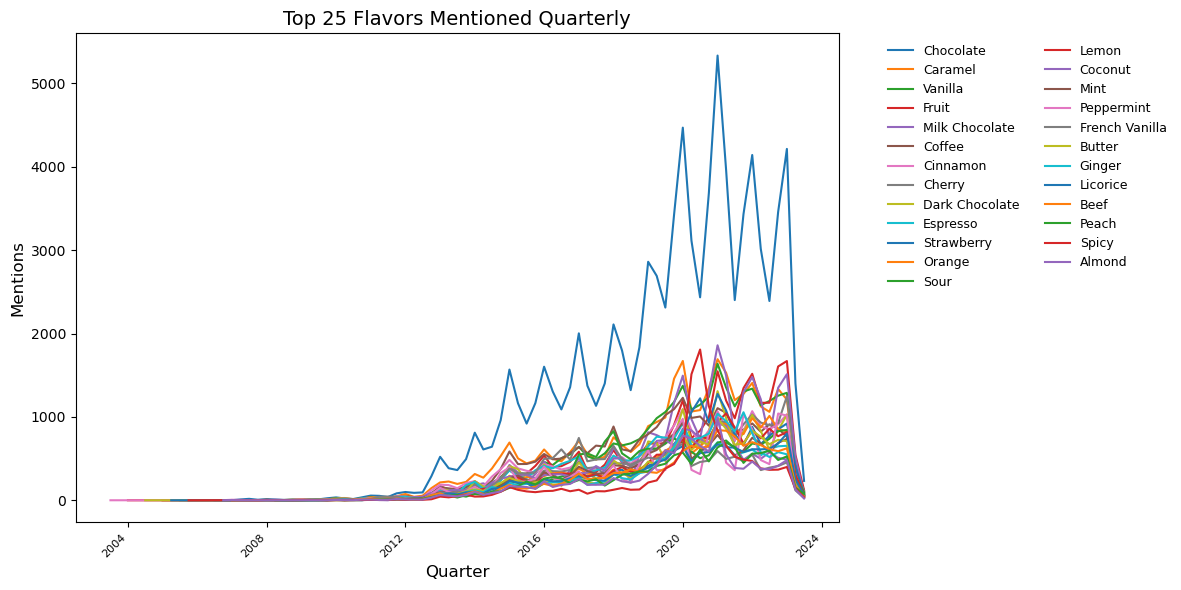

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

top25 = df_top['Flavor'].value_counts().head(25).index

for flavor in top25:
    subset = trend_df[trend_df['Flavor'] == flavor].sort_values('year_quarter')
    plt.plot(subset['year_quarter'].dt.to_timestamp(),   # ensures correct order
             subset['mention_count'],
             label=flavor)

plt.title("Top 25 Flavors Mentioned Quarterly", fontsize=14)
plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Mentions", fontsize=12)

# Rotate and shrink x-axis labels
plt.xticks(rotation=45, ha='right', fontsize=8)

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9, frameon=False)

# Use tight layout to fit everything neatly 
plt.tight_layout()
plt.show()


In [43]:
# Compute growth rate quarter over quarter
trend_df['growth_rate'] = trend_df.groupby('Flavor')['mention_count'].pct_change()

In [44]:
trend_df.head(10)

,year_quarter,Flavor,mention_count,growth_rate
37,2006Q4,Almond,2,NaN
55,2007Q1,Almond,4,1.0
90,2007Q2,Almond,2,-0.5
118,2007Q3,Almond,1,-0.5
304,2008Q4,Almond,1,0.0
353,2009Q1,Almond,1,0.0
405,2009Q2,Almond,1,0.0
511,2009Q4,Almond,1,0.0
577,2010Q1,Almond,5,4.0
645,2010Q2,Almond,2,-0.6


In [45]:
# Find most consistently growing flavors
top_growing = trend_df.groupby('Flavor')['growth_rate'].mean().sort_values(ascending=False)

In [46]:
# Calculate top 25 flavors with highest growth rate
top_growing = trend_df.groupby('Flavor')['growth_rate'].mean().sort_values(ascending=False).head(25)
top_growing.head(25)

Flavor
Whole Bean Coffee            0.861529
Cookies & Cream              0.772826
Party Mix                    0.768104
Just Black (Medium Roast)    0.544458
Milk Chocolate               0.516517
Cookies                      0.452031
Raw                          0.447292
Salty,Sweet                  0.374176
Matcha                       0.351290
Peppermint                   0.343959
Pumpkin Spice                0.328565
Grape                        0.323083
Pineapple                    0.291776
Apple                        0.276376
Zero ultra                   0.269234
Caramel                      0.267620
Decaf                        0.256848
Cheese                       0.254652
Raspberry                    0.247846
Peanut                       0.246828
Beef                         0.243844
Sweet                        0.243286
Chicken                      0.231138
Sweet & Hot                  0.230714
White Chocolate              0.228468
Name: growth_rate, dtype: float64

In [47]:
df.shape

(2318509, 18)

In [48]:
df_top.shape

(1061601, 18)

In [53]:
# Export merged dataframe as parquet chunks
chunk_size = 100_000  # 100K records per chunk
total_chunks = (len(df_top) + chunk_size - 1) // chunk_size

for i in tqdm(range(0, len(df_top), chunk_size)):
    chunk = df_top.iloc[i:i+chunk_size].copy()  # copy ensures slice is independent
    chunk['price'] = pd.to_numeric(chunk['price'].replace('—', np.nan), errors='coerce')
    chunk.to_parquet(f'df_top_chunk_{i//chunk_size:03d}.parquet', index=False)
    del chunk
    gc.collect()

print(f"Exported {total_chunks} parquet chunks")

100%|██████████| 11/11 [02:15<00:00, 12.30s/it]

Exported 11 parquet chunks


## Step 7: Building Advanced Models 

In [49]:
from sklearn.preprocessing import MinMaxScaler

# Compute total mentions
total_mentions = trend_df.groupby('Flavor')['mention_count'].sum()

# Combine total mentions and average growth rate into one DataFrame
trend_score_df = pd.DataFrame({'total_mentions': total_mentions, 'avg_growth': top_growing}).dropna()

# Normalize both columns between 0-1
scaler = MinMaxScaler()
trend_score_df[['mentions_norm', 'growth_norm']] = scaler.fit_transform(trend_score_df[['total_mentions', 'avg_growth']])

In [50]:
# Create a trend score by combining normalized mentions and growth
trend_score_df['trend_score'] =  (
    0.6 * trend_score_df['growth_norm'] +       # prioritize growth (momentum)
    0.4 * trend_score_df['mentions_norm']       # ensure enough popuarity (mentions)
    )

In [66]:
# Sort flavors by trend score
emerging_flavors = (trend_score_df.sort_values(by='trend_score', ascending=False).head(25).index.tolist())

print(emerging_flavors)


['Cookies & Cream', 'Whole Bean Coffee', 'Milk Chocolate', 'Party Mix', 'Caramel', 'Just Black (Medium Roast)', 'Peppermint', 'Raw', 'Cookies', 'Grape', 'Matcha', 'Beef', 'Pumpkin Spice', 'Salty,Sweet', 'Raspberry', 'Chicken', 'Peanut', 'Cheese', 'Decaf', 'Apple', 'Pineapple', 'Sweet & Hot', 'Zero ultra', 'Sweet', 'White Chocolate']


In [67]:
# Filter reviews for the top emerging flavors
df_emerging = df_top[df_top['Flavor'].isin(emerging_flavors)].copy()


In [68]:
df_emerging.head(10)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,title_meta,main_category,average_rating,rating_number,price,details,year_quarter,Flavor
45,5.0,great coffee at a great price.,Great coffee at a great price. Shipping was fa...,[],B00LY95FBU,B07LFJF6TR,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,2015-03-06 15:53:40.000,0,True,Subtle Earth Organic Coffee - Medium-Dark Roas...,Grocery,4.6,10591,30.95,"{'Manufacturer': 'CAFÉ Don Pablo', 'Part Numbe...",2015Q1,Whole Bean Coffee
66,3.0,Not Worth The Money,Did not realize that the bottles were so small...,[],B00ATUVIG6,B07BGJJYVB,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,2015-12-11 00:52:25.000,0,True,Amoretti Premium Peppermint Syrups 50ml 3 Pack...,Grocery,4.2,300,10.84,"{'Brand': 'Amoretti', 'Flavor': 'Peppermint', ...",2015Q4,Peppermint
115,5.0,Addictive!,These double dipped peanuts live up to their n...,[],B015OLF18A,B015OLF18A,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2022-10-01 03:13:52.363,0,True,Double Dipped Peanuts Milk Chocolate Covered P...,Grocery,4.0,428,18.98,"{'Brand': 'Zachary', 'Item Form': 'Toffee', 'O...",2022Q4,Milk Chocolate
117,1.0,I never should have bought these online!,So disappointing! I love Raisinets and these ...,[{'small_image_url': 'https://m.media-amazon.c...,B089FNVZK4,B089FNVZK4,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2022-08-08 19:24:39.486,0,True,Milk Chocolate Raisins | Nestle Raisinets Cali...,Grocery,4.3,475,None,"{'Brand': 'KMWA', 'Item Form': 'Beans', 'Choco...",2022Q3,Milk Chocolate
125,5.0,Wow!,I'm a chocoholic and only for Hersheys Milk Ch...,[],B07QKGNSL3,B089ZVV1P8,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2021-10-06 17:13:05.440,1,True,Tony’s Chocolonely 32% Milk Chocolate Caramel ...,Grocery,4.7,2191,75.86,"{'Brand': 'Tony's Chocolonely', 'Item Form': '...",2021Q4,Caramel
156,5.0,Lalees Boston Baked Beans - French Burnt Peanu...,really liked both of these candies: liked the ...,[],B08JQPB3RZ,B08JQPB3RZ,AEFKF6R2GUSK2AWPSWRR4ZO36JVQ,2021-06-26 23:11:53.508,0,True,Lalees Boston Baked Beans - French Burnt Peanu...,Grocery,4.2,136,None,"{'Brand': 'Lalees', 'Item Form': 'Toffee', 'Fl...",2021Q2,Peanut
180,4.0,Good quality almonds,Fresh taste. I will buy again. Greae for almon...,[],B07B7R7D44,B09RVM87D7,AET3VOB7PYHAKDAPEDTFGPSEE6QQ,2018-12-11 18:01:31.381,0,True,Raw Almonds Sweet Wild Harvested - Bulk - Natu...,Grocery,4.6,499,89.97,"{'Flavor': 'Sweet', 'Brand': 'Ellie's Best', '...",2018Q4,Sweet
268,5.0,Love them,I love all the flavors.,[],B00MBUT67U,B00MBUT67U,AHLC5H2CEWSAOXOA53VIIROLPZKA,2022-06-23 20:41:10.904,1,True,Werthers Bundle (4 Items) Variety Pack (Origin...,Grocery,4.6,1880,12.0,"{'Flavor': 'Caramel', 'Brand': 'Werther's', 'I...",2022Q2,Caramel
303,4.0,I’m hooked,Much too expensive but they are delicious,[],B00JHLA1FC,B07Y5K36YV,AFNT6ZJCYQN3WDIKUSWHJDXNND2Q,2019-09-26 20:30:22.741,0,True,"Werthers, Original, Caramel Popcorn, Classic C...",Grocery,4.4,917,58.48,"{'Flavor': 'Caramel', 'Brand': 'Werther's', 'I...",2019Q3,Caramel
373,4.0,Good buy.,These were good tasting and fresh Valentine ca...,[],B081ZG9DTH,B081ZG9DTH,AFIWYBPRAGQIAJOBA4QGIKL2BZAQ,2021-02-16 21:00:24.124,0,True,White Chocolate Peanut Butter Filled Hearts - ...,Grocery,3.9,14,None,"{'Brand': 'Blair Candy', 'Item Form': 'Hearts'...",2021Q1,White Chocolate


In [69]:
# Clean text (minimally) for sentiment analysis
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_emerging['clean_text'] = df_emerging['text'].apply(clean_text)

In [49]:
!pip install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 17.2 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 20.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [transformers] [transformers]


In [60]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 18.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.1/808.1 kB 16.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchaudio]2 [torchaudio]


In [77]:
# Extract the texts
texts = df_emerging['clean_text'].tolist()


In [78]:
import transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import numpy as np
import torch

# Load RoBERTa model
roberta_model = "cardiffnlp/twitter-roberta-base-sentiment-latest"

tokenizer = AutoTokenizer.from_pretrained(roberta_model)
model = AutoModelForSequenceClassification.from_pretrained(roberta_model)

label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

# Apply Batch sentiment prediction
def roberta_batch_sentiment(text_list, batch_size=32):
    scores = []

    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]

        tokens = tokenizer(
            batch,
            return_tensors='pt',
            truncation=True,
            max_length=512,
            padding='max_length'
        )

        # Remove token_type_ids (Roberta doesn't use them)
        if 'token_type_ids' in tokens:
            tokens.pop('token_type_ids')

        with torch.no_grad():
            output = model(**tokens)

        logits = output.logits.detach().numpy()

        for row in logits:
            probs = softmax(row)
            label = label_map[np.argmax(probs)]
            score = probs[np.argmax(probs)]

            if label == 'positive':
                scores.append(score)
            elif label == 'negative':
                scores.append(-score)
            else:
                scores.append(0)

    return scores

df_emerging['sentiment_score_roberta'] = roberta_batch_sentiment(texts)


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [57]:
!pip install tf-keras

  Using cached tensorflow-2.20.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (4.5 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 15.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 MB 13.8 MB/s  0:00:14m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 15.1 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.3
    Uninstalling protobuf-4.25.3:
      Successfully uninstalled protobuf-4.25.3━━ 0/4 [protobuf]
  Attempting uninstall: tensorboard━━━━━━━━━━━━━ 0/4 [protobuf]
    Found existing installation: tensorboard 2.19.032m0/4 [protobuf]
    Uninstalling tensorboard-2.19.0:━━━━━━━━ 0/4 [protobuf]
      Successfully uninstalled tensorboard-2.19.00/4 [protobuf]
  Attempting uninstall: tensorflow90m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/4 [tensorboard]
    Found existing installation: tensorflow 2.19.1━━━━━━━━━━━━ 1/4 [tenso

In [ ]:
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from multiprocessing import Pool, cpu_count

distilbert_model = "distilbert-base-uncased-finetuned-sst-2-english"

tokenizer = AutoTokenizer.from_pretrained(distilbert_model)
model = AutoModelForSequenceClassification.from_pretrained(distilbert_model)
model.eval()
device = torch.device("cpu")
model.to(device)

# CPU batch inference
def predict_batch(text_batch):
    encoded = tokenizer(
        text_batch,
        truncation=True,
        max_length=128,     # major speed improvement
        padding=True,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        logits = model(**encoded).logits

    probs = torch.nn.functional.softmax(logits, dim=-1).cpu().numpy()

    results = []
    for p in probs:
        neg, pos = p
        results.append(pos if pos > neg else -neg)

    return results

# Multiprocessing pipeline(CPU parallel)
def sentiment_parallel(df, text_col, batch_size=64, workers=None):
    if workers is None:
        workers = max(cpu_count() - 1, 1)

    texts = df[text_col].fillna("").astype(str).tolist()

    batches = [texts[i:i+batch_size] for i in range(0, len(texts), batch_size)]

    print(f"CPU cores used: {workers}")
    print(f"Total batches: {len(batches)}")

    with Pool(workers) as pool:
        results = pool.map(predict_batch, batches)

    # Flatten nested list
    return [x for batch in results for x in batch]

df_emerging['sentiment_score_distilbert'] = sentiment_parallel(df_emerging, text_col='clean_text', batch_size=64, workers=6)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

CPU cores used: 6
Total batches: 3906


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after

In [ ]:
# Aggregate sentiment by flavor & quarter
sentiment_trend = (df_emerging.groupby(['Flavor', 'year_quarter'])['sentiment_score_roberta'].mean().reset_index())
sentiment_trend.head(25)
 


,Flavor,year_quarter,sentiment_score_roberta
0,Apple,2008Q4,0.977215
1,Apple,2009Q1,0.619140
2,Apple,2009Q3,0.695162
3,Apple,2009Q4,0.860820
4,Apple,2010Q1,-0.546881
5,Apple,2010Q2,0.346808
6,Apple,2010Q3,-0.347601
7,Apple,2010Q4,0.009782
8,Apple,2011Q1,0.275241
9,Apple,2011Q2,0.208174


In [ ]:
# aggregate sentiment by flavor & quarter
sentiment_trend_distil = (df_emerging.groupby(['Flavor', 'year_quarter'])['sentiment_score_distilbert'].mean().reset_index())
sentiment_trend_distil.head(25)

In [ ]:
# Compute  distilBERT sentiment momentum
sentiment_trend_distil = sentiment_trend_distil.sort_values(by=['Flavor', 'year_quarter'])        # Sort each flavor's sentiment by quarter
sentiment_trend_distil['sentiment_growth]'] = sentiment_trend_distil.groupby('Flavor')['sentiment_score_distilbert'].pct_change()
sentiment_trend_distil.head(25)


Series([], Name: clean_text, dtype: object)

In [ ]:
# Compute roBERTa sentiment momentum
sentiment_trend = sentiment_trend.sort_values(by=['Flavor', 'year_quarter'])        # Sort each flavor's sentiment by quarter
sentiment_trend['sentiment_growth'] = sentiment_trend.groupby('Flavor')['sentiment_score_roberta'].pct_change()
sentiment_trend.head(25)

,Flavor,year_quarter,sentiment_score_roberta,sentiment_growth
0,Apple,2008Q4,0.977215,NaN
1,Apple,2009Q1,0.619140,-0.366424
2,Apple,2009Q3,0.695162,0.122786
3,Apple,2009Q4,0.860820,0.238301
4,Apple,2010Q1,-0.546881,-1.635302
5,Apple,2010Q2,0.346808,-1.634156
6,Apple,2010Q3,-0.347601,-2.002287
7,Apple,2010Q4,0.009782,-1.028142
8,Apple,2011Q1,0.275241,27.137295
9,Apple,2011Q2,0.208174,-0.243667


In [84]:
# Create a combined trend + sentiment score
final_df = trend_score_df.merge(
    sentiment_trend.groupby('Flavor')['sentiment_score_roberta'].mean().rename('avg_sentiment'),
    left_index=True,
    right_index=True,
    how='inner'
)

final_df = final_df.merge(
    sentiment_trend.groupby('Flavor')['sentiment_growth'].mean().rename('sentiment_momentum'),
    left_index=True,
    right_index=True,
    how='inner'
)

# Clean momentum column
final_df['sentiment_momentum'] = final_df['sentiment_momentum'].replace([np.inf, -np.inf], np.nan)
final_df['sentiment_momentum'] = final_df['sentiment_momentum'].fillna(0)

# Clean sentiment column
final_df['avg_sentiment'] = final_df['avg_sentiment'].replace([np.inf, -np.inf], np.nan)
final_df['avg_sentiment'] = final_df['avg_sentiment'].fillna(0)



In [86]:
# Normalize sentiment for equal weighting
final_df[['sent_norm', 'sent_momentum_norm']] = scaler.fit_transform(
    final_df[['avg_sentiment', 'sentiment_momentum']]
)

final_df['final_emerging_score'] = (
    0.5 * final_df['trend_score'] +
    0.3 * final_df['sent_norm'] +
    0.2 * final_df['sent_momentum_norm']
)

In [87]:
final_df.head(15)

,total_mentions,avg_growth,mentions_norm,growth_norm,trend_score,avg_sentiment,sentiment_momentum,sent_norm,sent_momentum_norm,final_emerging_score
Flavor,,,,,,,,,,
Apple,6040,0.276376,0.082007,0.075677,0.078209,0.425004,0.268691,0.420892,0.466784,0.258729
Beef,15371,0.243844,0.388947,0.024289,0.170153,0.520348,0.000000,0.646666,0.261025,0.331281
Caramel,33947,0.267620,1.000000,0.061847,0.437108,0.576717,0.054936,0.780147,0.303094,0.513217
Cheese,8630,0.254652,0.167204,0.041362,0.091699,0.429220,0.000000,0.430875,0.261025,0.227317
Chicken,12303,0.231138,0.288026,0.004218,0.117741,0.561845,0.000000,0.744931,0.261025,0.334555
Cookies,3547,0.452031,0.000000,0.353146,0.211888,0.437866,0.138791,0.451349,0.367309,0.314810
Cookies & Cream,13089,0.772826,0.313882,0.859883,0.641482,0.455823,0.071990,0.493871,0.316153,0.532133
Decaf,7463,0.256848,0.128816,0.044831,0.078425,0.616151,0.328145,0.873527,0.512313,0.403733
Grape,10642,0.323083,0.233388,0.149457,0.183030,0.566025,0.051051,0.754829,0.300119,0.377987


In [ ]:
# Final ranked emerging flavors
ranked_emerging = final_df.sort_values('final_emerging_score', ascending=False).head(15)
ranked_emerging


,total_mentions,avg_growth,mentions_norm,growth_norm,trend_score,avg_sentiment,sentiment_momentum,sent_norm,sent_momentum_norm,final_emerging_score
Flavor,,,,,,,,,,
Whole Bean Coffee,6666,0.861529,0.102599,1.000000,0.641039,0.669560,0.007664,1.000000,0.266894,0.673898
Cookies & Cream,13089,0.772826,0.313882,0.859883,0.641482,0.455823,0.071990,0.493871,0.316153,0.532133
Caramel,33947,0.267620,1.000000,0.061847,0.437108,0.576717,0.054936,0.780147,0.303094,0.513217
Milk Chocolate,27756,0.516517,0.796349,0.455011,0.591546,0.475552,-0.021071,0.540588,0.244889,0.506927
Raw,4155,0.447292,0.020000,0.345661,0.215396,0.592207,0.486627,0.816827,0.633676,0.479482
Just Black (Medium Roast),4092,0.544458,0.017928,0.499147,0.306659,0.571872,0.039039,0.768674,0.290920,0.442116
Sweet,4758,0.243286,0.039836,0.023407,0.029978,0.555654,0.964992,0.730269,1.000000,0.434070
Decaf,7463,0.256848,0.128816,0.044831,0.078425,0.616151,0.328145,0.873527,0.512313,0.403733
Peppermint,17680,0.343959,0.464901,0.182433,0.295420,0.542815,-0.057851,0.699868,0.216723,0.401015


In [ ]:
# Create a combined trend + sentiment score
distil_final_df = trend_score_df.merge(
    sentiment_trend_distil.groupby('Flavor')['sentiment_score_roberta'].mean().rename('avg_sentiment'),
    left_index=True,
    right_index=True,
    how='inner'
)

distil_final_df = distil_final_df.merge(
    sentiment_trend_distil.groupby('Flavor')['sentiment_growth'].mean().rename('sentiment_momentum'),
    left_index=True,
    right_index=True,
    how='inner'
)

# Clean momentum column
distil_final_df['sentiment_momentum'] = distil_final_df['sentiment_momentum'].replace([np.inf, -np.inf], np.nan)
distil_final_df['sentiment_momentum'] = distil_final_df['sentiment_momentum'].fillna(0)

# Clean sentiment column
distil_final_df['avg_sentiment'] = distil_final_df['avg_sentiment'].replace([np.inf, -np.inf], np.nan)
distil_final_df['avg_sentiment'] = distil_final_df['avg_sentiment'].fillna(0)

(249924, 20)

In [ ]:
# Normalize sentiment for equal weighting
distil_final_df[['sent_norm', 'sent_momentum_norm']] = scaler.fit_transform(
    distil_final_df[['avg_sentiment', 'sentiment_momentum']]
)

distil_final_df['final_emerging_score'] = (
    0.5 * final_df['trend_score'] +
    0.3 * final_df['sent_norm'] +
    0.2 * final_df['sent_momentum_norm']
)

In [ ]:
distil_final_df.head(15)

In [ ]:
# Final ranked emerging flavors
distil_ranked_emerging = distil_final_df.sort_values('final_emerging_score', ascending=False).head(15)
distil_ranked_emerging

In [ ]:
df_emerging.shape